# **House Price Prediction**


#House Price Prediction Using Machine Learning

Objective

The objective of this project is to predict house prices using property features such as area, number of bedrooms, bathrooms, parking spaces, and furnishing status. Two regression models are built and compared:

1.Linear Regression

2.Random Forest Regressor

The project also identifies the most influential factors affecting house prices through visualization and feature importance analysis.

##Task 1 — Data Loading & Exploration

#Step 1:
#Import Required Libraries


Before starting, import all necessary libraries for data manipulation, visualization, model building, and evaluation.

In [1]:
# Data Manipulation Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#Step 2:
#Load Dataset


The dataset is loaded using Pandas. The first few rows are displayed to understand the structure of the data.

In [2]:
df = pd.read_csv("Housing.csv")

print("Dataset Loaded Successfully")

df.head(10)

Dataset Loaded Successfully


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


#Step 3:
#Data Exploration


Data exploration helps understand the dataset's dimensions, data types, and quality.

#3.1 Dataset Shape

In [3]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(545, 13)


#3.2 Dataset Columns

In [4]:
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


# 3.3 Dataset Information


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


#3.4 Statistical Summary

In [6]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


#3.5 Missing Values

In [7]:
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


#3.6 Duplicate Records

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


#Task 2 — Data Cleaning


#Step 4:
#Data Cleaning


Data cleaning improves the quality of the dataset by removing inconsistencies.

#4.1 Remove Duplicate Rows

In [9]:
df = df.drop_duplicates()

print("Shape After Removing Duplicates:")
print(df.shape)

Shape After Removing Duplicates:
(545, 13)


#4.2 Convert Yes/No Columns to Numeric


Machine learning models require numerical data. Therefore, Yes/No values are converted to 1 and 0.

In [10]:
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_columns:
    df[col] = df[col].map({
        'yes': 1,
        'no': 0
    })

#4.3 One-Hot Encoding


The furnishingstatus column contains multiple categories. One-Hot Encoding converts them into separate numerical columns.

In [11]:
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    dtype='int',
    drop_first=True

)

In [12]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


#Step 5: Correlation Analysis


Correlation helps identify relationships between features and the target variable.

In [13]:
correlation = df.corr()

correlation['price'].sort_values(
    ascending=False
)

,price
price,1.000000
area,0.535997
bathrooms,0.517545
airconditioning,0.452954
stories,0.420712
parking,0.384394
bedrooms,0.366494
prefarea,0.329777
mainroad,0.296898
guestroom,0.255517


#Step 6: Feature Selection


Separate the target variable from independent variables.

In [14]:
X = df.drop('price', axis=1)

y = df['price']

#Task 3 — Model Building

#Step 7: Train-Test Split


The dataset is divided into training and testing sets.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

#Step 8: Linear Regression Model


Linear Regression establishes a linear relationship between independent variables and house prices.

In [16]:
lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

LinearRegression()

#Make Predictions

In [17]:
lr_predictions = lr_model.predict(X_test)

#Evaluate Model

In [19]:
lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_predictions
    )
)

lr_r2 = r2_score(
    y_test,
    lr_predictions
)

print("Linear Regression Results")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Results
MAE: 970043.4039201637
RMSE: 1324506.9600914384
R² Score: 0.6529242642153185


#Step 9: Random Forest Regressor


Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy.

In [20]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestRegressor(random_state=42)

#Make Predictions

In [21]:
rf_predictions = rf_model.predict(X_test)

#Evaluate Model

In [22]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE: 1022560.0527522935
RMSE: 1401496.8425384816
R² Score: 0.6114024924156645


#Step 10: Model Comparison


Compare both models using evaluation metrics.

In [23]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        lr_mae,
        rf_mae
    ],
    'RMSE': [
        lr_rmse,
        rf_rmse
    ],
    'R2 Score': [
        lr_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


#Task 4 — Visualization

#Step 11: Visualization 1
Distribution of House Prices


A histogram shows how house prices are distributed.

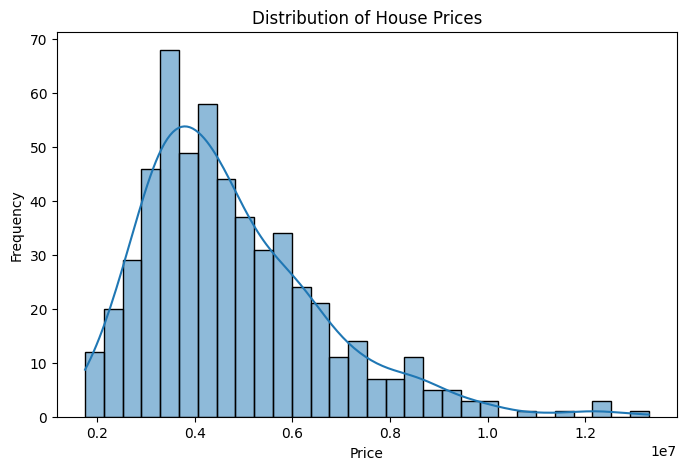

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['price'],
    bins=30,
    kde=True
)

plt.title(
    "Distribution of House Prices"
)

plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig(
    "chart1_price_distribution.png"
)

plt.show()

Step 12: Visualization 2
Correlation Heatmap


A heatmap visualizes correlations among all features.

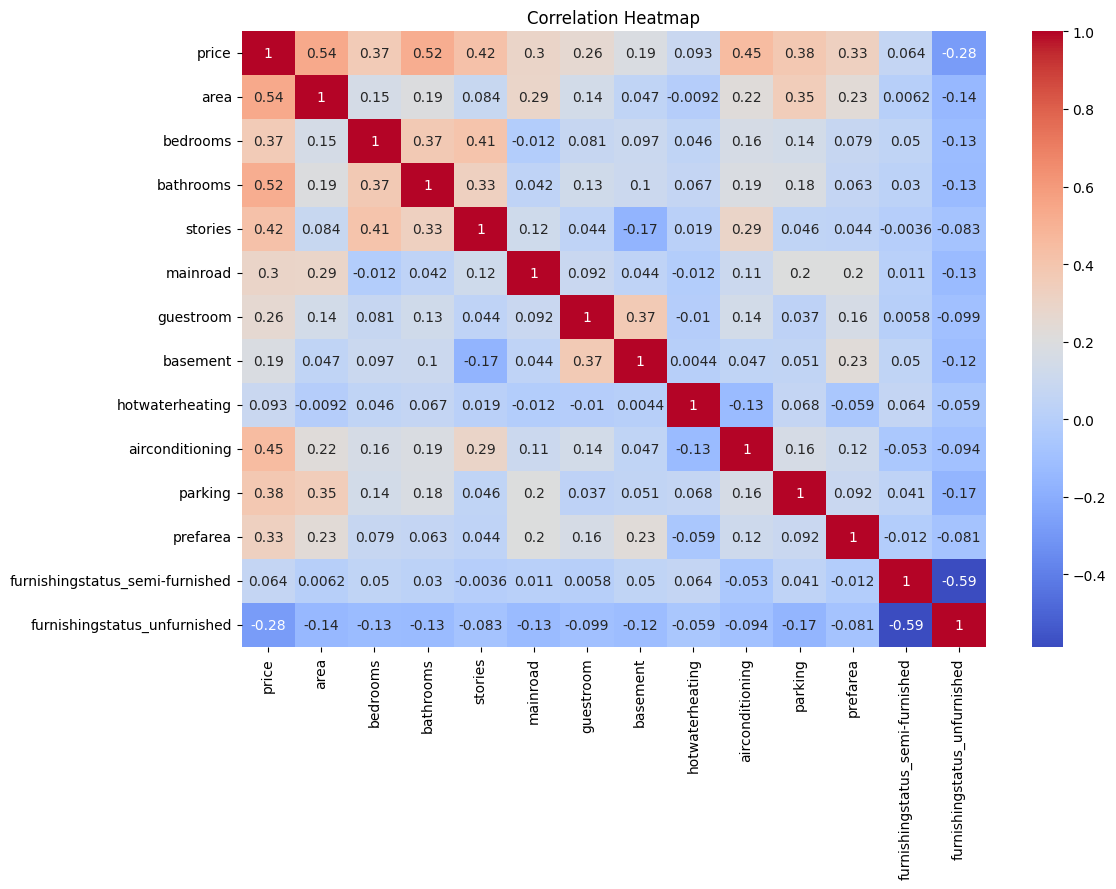

In [25]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Correlation Heatmap"
)

plt.savefig(
    "chart2_correlation_heatmap.png"
)

plt.show()

#Step 13: Visualization 3
Actual vs Predicted Prices


This plot compares actual house prices with predicted values.

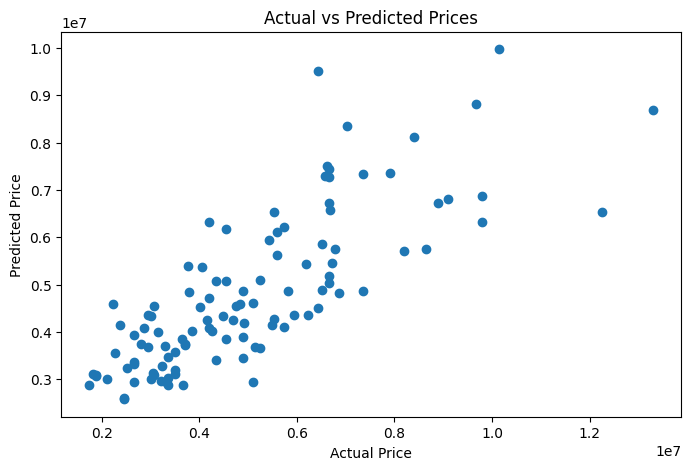

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Actual vs Predicted Prices"
)

plt.savefig(
    "chart3_actual_vs_predicted.png"
)

plt.show()

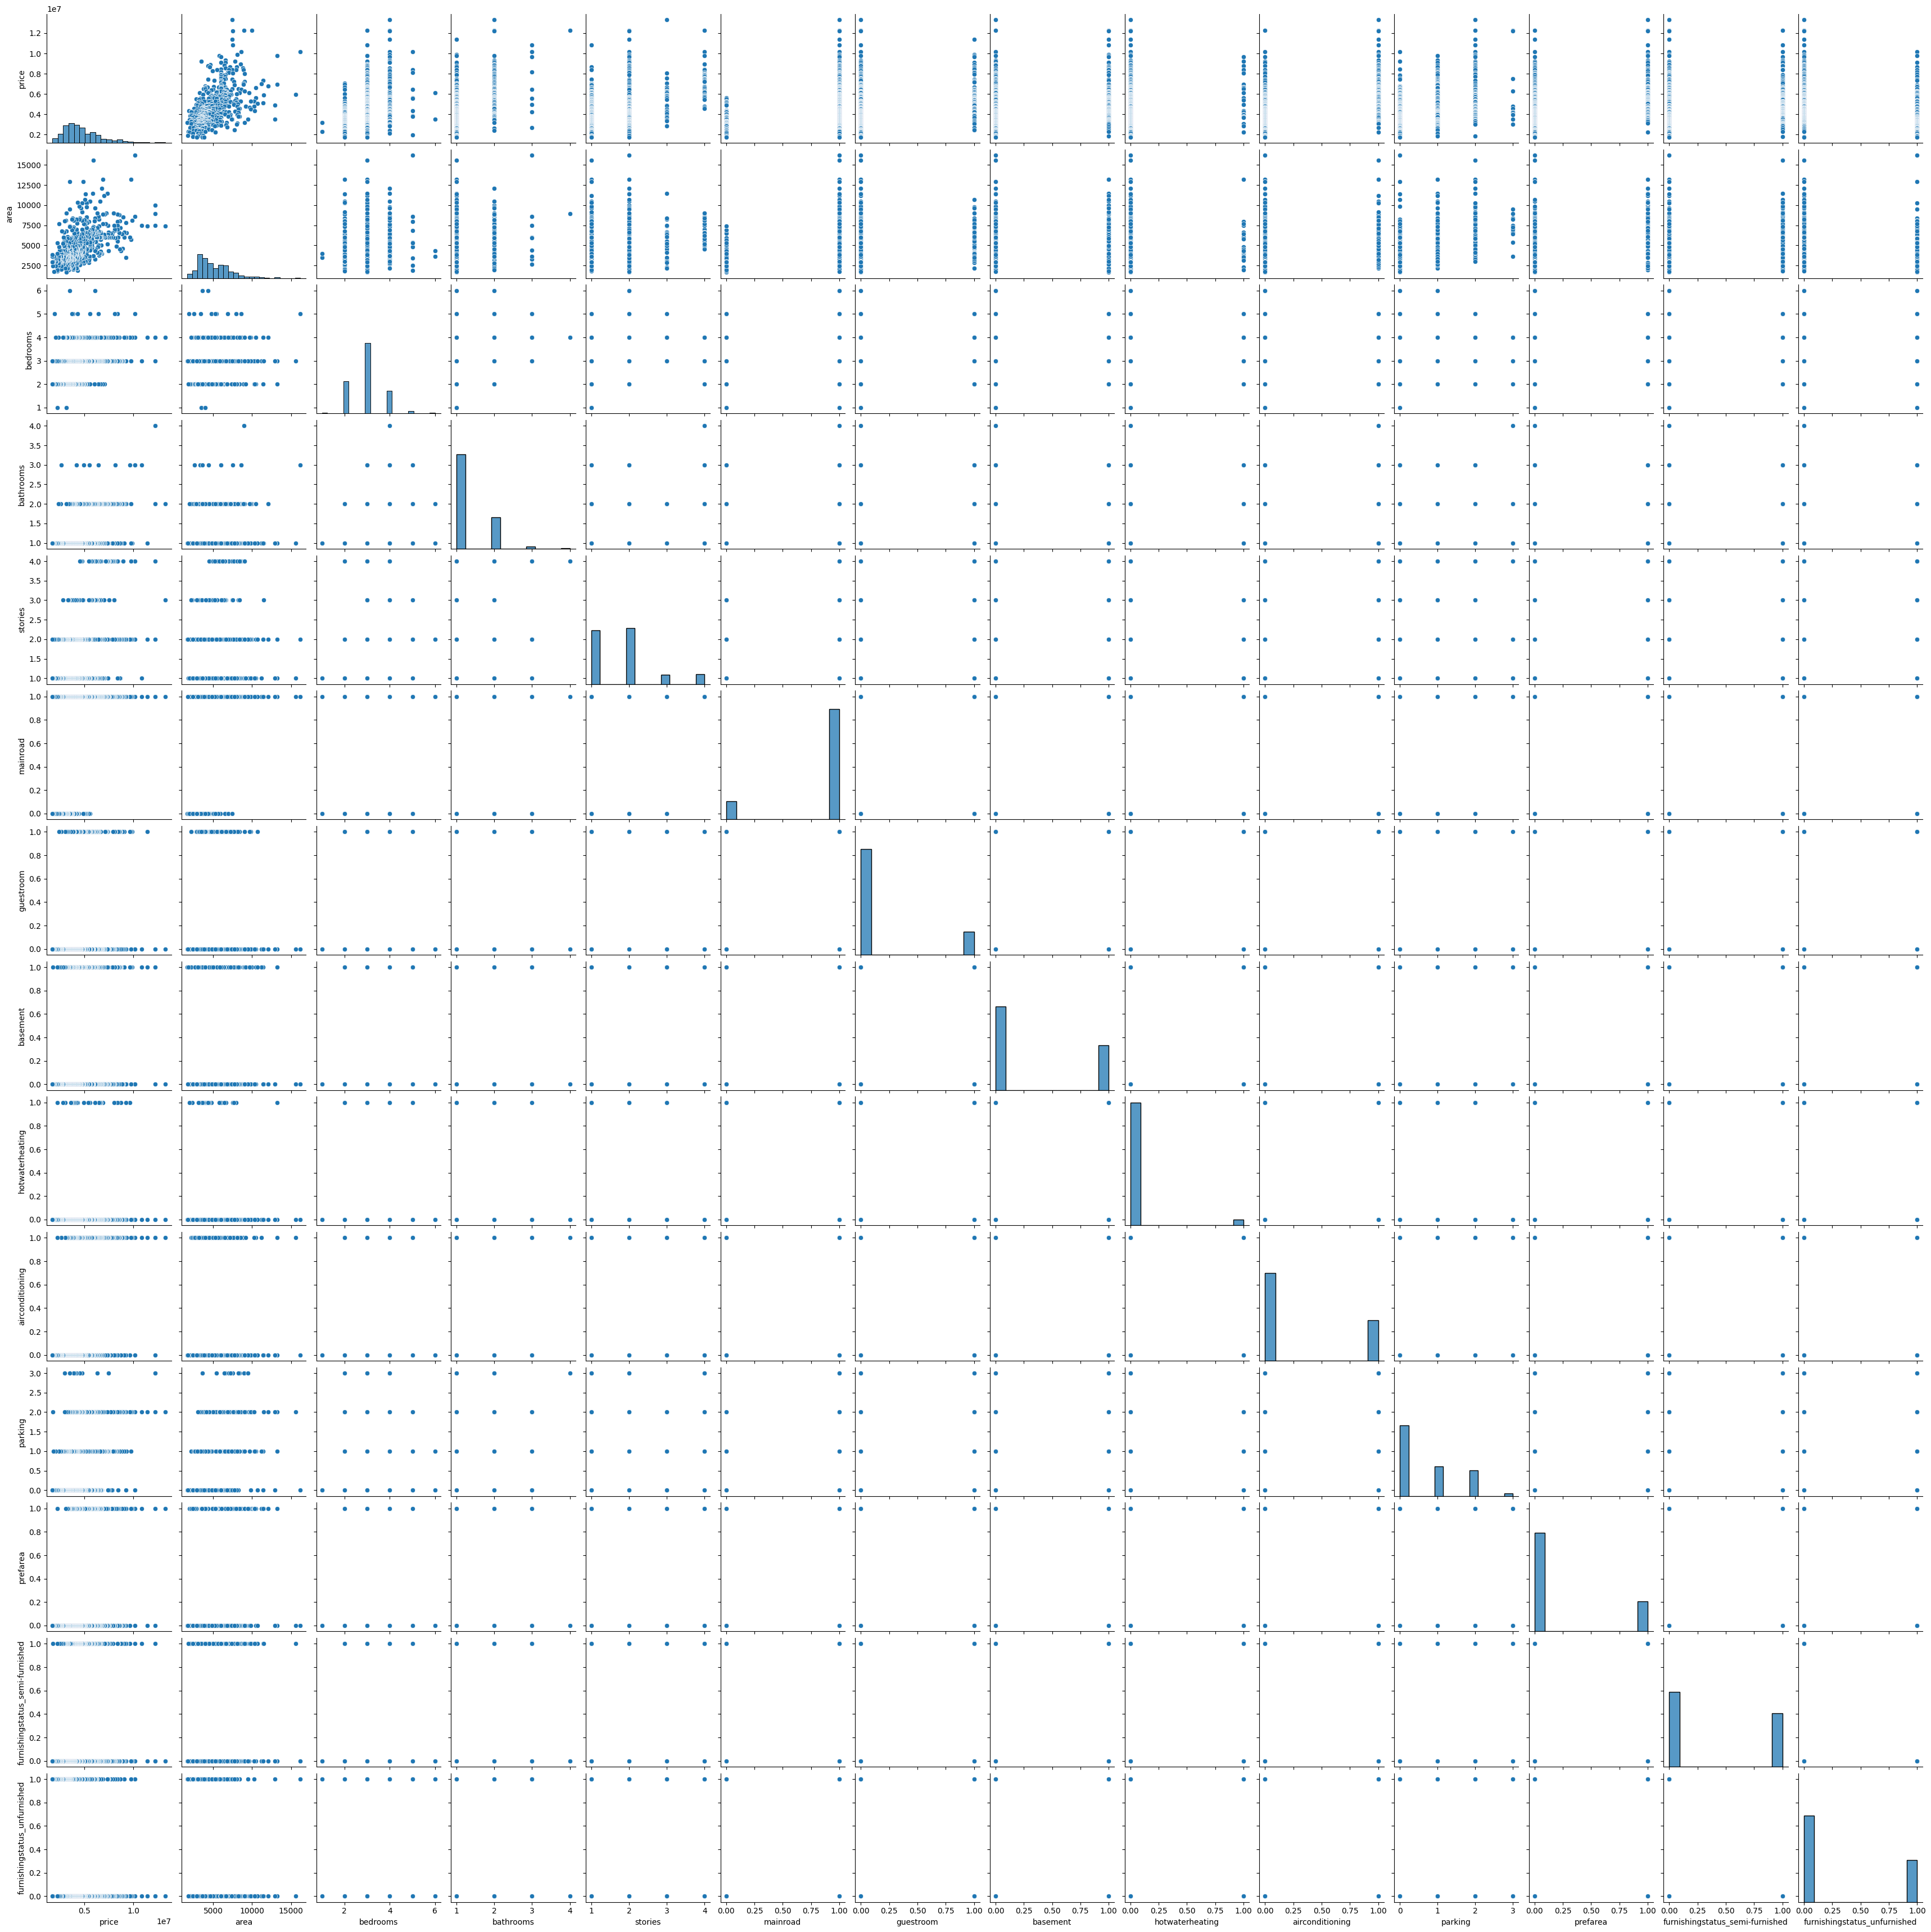

In [31]:
sns.pairplot(df)
plt.show()

#Task 5 — Insights & Summary


#Step 14: Feature Importance


Random Forest provides feature importance scores indicating which features most influence house prices.

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                            Feature  Importance
0                              area    0.467917
2                         bathrooms    0.151526
8                   airconditioning    0.062718
9                           parking    0.057820
3                           stories    0.057137
1                          bedrooms    0.048608
12     furnishingstatus_unfurnished    0.034998
6                          basement    0.030804
10                         prefarea    0.030519
7                   hotwaterheating    0.017255
5                         guestroom    0.016638
11  furnishingstatus_semi-furnished    0.013764
4                          mainroad    0.010296


#Feature Importance Chart

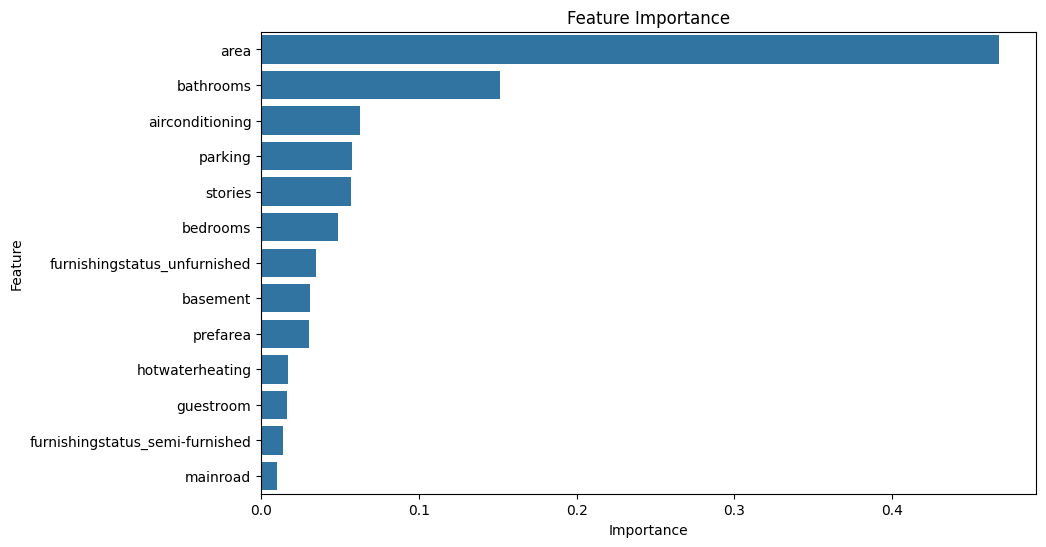

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Feature Importance"
)

plt.savefig(
    "chart4_feature_importance.png"
)

plt.show()

#Step 15: Conclusion

In [29]:
print("Top 5 Important Features")

print(
    importance.head(5)
)

Top 5 Important Features
           Feature  Importance
0             area    0.467917
2        bathrooms    0.151526
8  airconditioning    0.062718
9          parking    0.057820
3          stories    0.057137


#Insights & Summary

The analysis revealed that area, bathrooms, air conditioning, parking, and preferred area (prefarea) were the most influential factors affecting house prices. The Linear Regression model achieved an R² score of approximately 0.65, which means it was able to explain about 65% of the variation in house prices, indicating reasonably good prediction accuracy. One surprising finding was that some amenities, such as guest rooms and hot water heating, had a smaller impact on price than expected, while the size of the house remained the dominant factor. The results also showed that houses located in preferred areas generally commanded higher prices. Based on these findings, a real estate business should focus on properties with larger areas, sufficient bathrooms, parking facilities, and modern amenities, as these features significantly increase property value and buyer interest.